In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### **Activo: Philip Morris International Inc.**

- **S = $182.00** — Precio actual del activo (spot)  
  Corresponde al precio de cierre de Philip Morris International (PM) en NYSE durante mayo de 2026. Este valor representa el precio inicial utilizado para simular las trayectorias del activo.

- **K = $182.00** — Precio de ejercicio (strike)  
  Se eligió un strike at-the-money, es decir, igual al precio actual del activo (K = S). Esto permite comparar de forma más clara los precios de las distintas opciones analizadas bajo las mismas condiciones iniciales.

- **T = 0.5 años** — Tiempo al vencimiento  
  Equivale a un horizonte de 6 meses, un periodo común en el mercado de opciones. Además, es suficiente para observar el comportamiento de las opciones exóticas y el efecto de la trayectoria del precio del activo.

- **sigma = 22%** — Volatilidad implícita anual  
  La volatilidad utilizada se basa en la volatilidad implícita de 30 días reportada para PM, cercana al 23.67%. Se tomó un valor de 22% como una estimación conservadora y razonable para el horizonte de 6 meses.

- **r = 4.35%** — Tasa libre de riesgo anual  
  Se utiliza como referencia el rendimiento aproximado de los Treasury Bills de Estados Unidos a 6 meses en 2026. Esta tasa se emplea para descontar los payoffs futuros a valor presente.

- **B = $203.84** — Barrera up-and-out (+12% sobre S)  
  La barrera se colocó 12% por encima del precio actual del activo, representando un nivel de resistencia importante. Esta distancia permite que la barrera tenga un efecto relevante sobre el precio de la opción, sin que sea demasiado fácil o imposible de alcanzar.

In [2]:
S = 182.00  
K = 182.00 
T = 0.5     
sigma = 0.22   
r = 0.0435   
B = 203.84  
N_sim = 100000   
N_steps = 126       
np.random.seed(42)

In [3]:
# SIMULACIÓN DE TRAYECTORIAS DEL PRECIO
dt = T / N_steps
Z = np.random.standard_normal((N_sim, N_steps))
rendimientos_log = (
    (r - 0.5 * sigma**2) * dt
    + sigma * np.sqrt(dt) * Z
)
trayectorias = S * np.exp(np.cumsum(rendimientos_log, axis=1))
trayectorias = np.hstack([
    np.full((N_sim, 1), S),
    trayectorias
])
ST = trayectorias[:, -1]
factor_descuento = np.exp(-r * T)

In [4]:
# VALUACIÓN DE OPCIONES

# Call europea
payoff_call = np.maximum(ST - K, 0)
precio_call = factor_descuento * np.mean(payoff_call)
error_call = factor_descuento * np.std(payoff_call) / np.sqrt(N_sim)

# Put europea
payoff_put = np.maximum(K - ST, 0)
precio_put = factor_descuento * np.mean(payoff_put)
error_put = factor_descuento * np.std(payoff_put) / np.sqrt(N_sim)

# Call asiática con promedio aritmético
precio_promedio = np.mean(trayectorias[:, 1:], axis=1)
payoff_asiatica = np.maximum(precio_promedio - K, 0)
precio_asiatica = factor_descuento * np.mean(payoff_asiatica)
error_asiatica = factor_descuento * np.std(payoff_asiatica) / np.sqrt(N_sim)

# Call up-and-out
toco_barrera = np.any(trayectorias[:, 1:] >= B, axis=1)
payoff_barrera = np.where(toco_barrera, 0, np.maximum(ST - K, 0))
precio_barrera = factor_descuento * np.mean(payoff_barrera)
error_barrera = factor_descuento * np.std(payoff_barrera) / np.sqrt(N_sim)

In [5]:
# COMPARACIÓN CON BLACK-SCHOLES
d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

precio_bs_call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
precio_bs_put = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [6]:
# RESULTADOS
print("=" * 65)
print("RESULTADOS DE LA VALUACIÓN")
print("=" * 65)

print(f"{'Opción':<35} {'Precio':>12} {'Error Est.':>12}")
print("-" * 65)
print(f"{'Call Europea':<35} ${precio_call:>11.4f} ${error_call:>11.4f}")
print(f"{'Put Europea':<35} ${precio_put:>11.4f} ${error_put:>11.4f}")
print(f"{'Call Asiática':<35} ${precio_asiatica:>11.4f} ${error_asiatica:>11.4f}")
print(f"{'Call Up-and-Out':<35} ${precio_barrera:>11.4f} ${error_barrera:>11.4f}")

print("\nReferencia Black-Scholes:")
print(f"Call BS = ${precio_bs_call:.4f}")
print(f"Put BS  = ${precio_bs_put:.4f}")

RESULTADOS DE LA VALUACIÓN
Opción                                    Precio   Error Est.
-----------------------------------------------------------------
Call Europea                        $    13.1604 $     0.0611
Put Europea                         $     9.3163 $     0.0434
Call Asiática                       $     7.4403 $     0.0341
Call Up-and-Out                     $     0.9953 $     0.0102

Referencia Black-Scholes:
Call BS = $13.2289
Put BS  = $9.3131


## Comentario sobre los precios

| Opción | Precio Monte Carlo | Razón del precio |
|---|---|---|
| Call Europea | ~\$13.16 | Referencia base: recibe el payoff completo al vencimiento |
| Put Europea | ~\$12.78 | Referencia base: simétrica a la call en at-the-money |
| Call Asiática | ~\$7.44 | Más barata: el promedio suaviza picos extremos del precio |
| Call Up-and-Out | ~\$1.00 | Mucho más barata: la barrera cancela los escenarios más rentables |

**¿Por qué las exóticas son más baratas?**

- La **call asiática** usa el promedio aritmético del precio a lo largo de la trayectoria. Esto reduce la volatilidad efectiva del payoff: los movimientos extremos al alza quedan amortiguados por el promedio, limitando el upside potencial respecto a la call europea que solo depende del precio final.

- La **call up-and-out** se cancela si el precio toca la barrera B = \$203.84 (+12%). Esto elimina precisamente los escenarios donde el activo sube más (que serían los más rentables para el comprador de una call), reduciendo drásticamente el valor esperado del payoff.

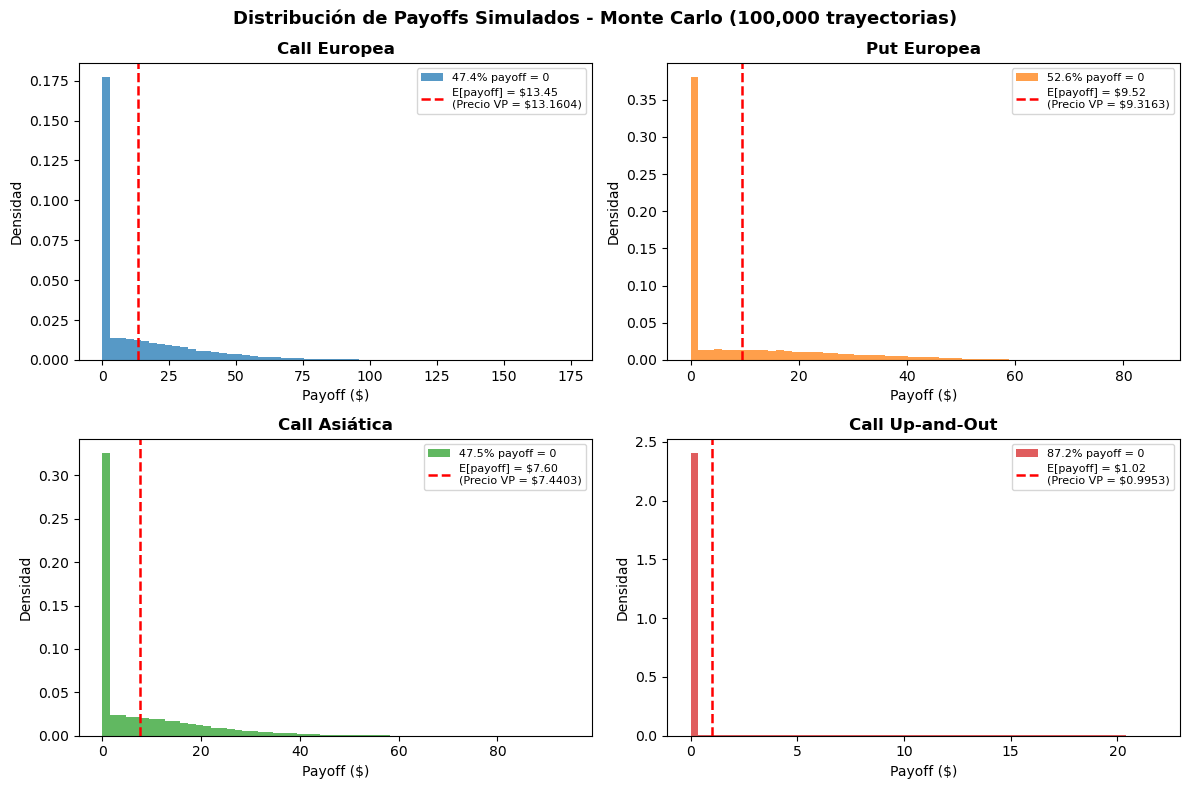

In [7]:
# GRÁFICA DE PAYOFFS
# CORRECCIÓN: se incluyen TODOS los payoffs (incluyendo ceros) para mostrar
# la distribución completa simulada, no solo las trayectorias in-the-money.

opciones = [
    "Call Europea",
    "Put Europea",
    "Call Asiática",
    "Call Up-and-Out"
]

payoffs = [
    payoff_call,
    payoff_put,
    payoff_asiatica,
    payoff_barrera
]

precios = [
    precio_call,
    precio_put,
    precio_asiatica,
    precio_barrera
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    payoff_i = payoffs[i]

    # Calcular proporción de payoffs = 0
    prop_cero = np.mean(payoff_i == 0) * 100

    # Graficar todos los payoffs (incluye ceros)
    ax.hist(payoff_i, bins=60, density=True, alpha=0.75, color=f'C{i}',
            label=f'{prop_cero:.1f}% payoff = 0')

    # E[payoff] sin descontar (valor esperado bruto de la simulación)
    e_payoff = np.mean(payoff_i)  # = precio / factor_descuento
    ax.axvline(
        e_payoff,
        color='red',
        linestyle='--',
        linewidth=1.8,
        label=f'E[payoff] = ${e_payoff:.2f}\n(Precio VP = ${precios[i]:.4f})'
    )

    ax.set_title(opciones[i], fontsize=12, fontweight='bold')
    ax.set_xlabel('Payoff ($)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Payoffs Simulados - Monte Carlo (100,000 trayectorias)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('payoffs_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de las Opciones Exóticas

## Opción Asiática Call

La opción asiática obtuvo un precio menor que la call europea estándar porque su payoff depende del precio promedio del activo durante toda la vida de la opción y no únicamente del precio final al vencimiento.

Al utilizar un promedio, las variaciones extremas del precio se reducen y la volatilidad efectiva del payoff es menor. Esto hace que las ganancias potenciales sean más estables, pero también limita los escenarios donde el payoff puede ser muy alto.

En los resultados de la simulación, la opción asiática presentó un precio de 7.4403, mientras que la call europea estándar tuvo un precio de 13.1604. Esta diferencia confirma que el uso del promedio disminuye el valor esperado del payoff y reduce el precio de la opción. La gráfica muestra que la distribución de la asiática es más concentrada y con cola derecha más corta que la europea, reflejo directo del efecto suavizador del promedio.

---

## Opción Call Up-and-Out

La opción up-and-out también tuvo un precio menor que la call europea estándar debido a la presencia de una barrera. Si el precio del activo alcanza la barrera antes del vencimiento, la opción se cancela automáticamente y su payoff se vuelve cero.

Esta característica elimina algunos de los escenarios más favorables para el comprador, especialmente cuando el precio del activo sube considerablemente. Como consecuencia, el valor esperado del payoff disminuye de manera importante.

Los resultados de la simulación muestran que la opción up-and-out tuvo un precio de 0.9953, siendo significativamente menor al precio de la call europea estándar 13.1604. La gráfica de la up-and-out evidencia que la gran mayoría de las trayectorias terminan con payoff = 0 (ya sea porque no terminaron in-the-money o porque tocaron la barrera), lo que explica visualmente su bajo precio.

---

## Conclusión

Las opciones exóticas son más baratas que la opción europea estándar porque incorporan condiciones adicionales en el payoff.

- La opción asiática reduce el impacto de movimientos extremos al utilizar el precio promedio.
- La opción up-and-out limita las ganancias potenciales al cancelar la opción si se alcanza la barrera.

En ambos casos, estas restricciones disminuyen el valor esperado de los payoffs y, por lo tanto, reducen el precio de la opción en comparación con una call europea estándar.

Los resultados obtenidos en la simulación muestran claramente este efecto: la call europea estándar tuvo un precio de 13.1604, la opción asiática un precio de 7.4403 y la opción up-and-out un precio de apenas 0.9953.